In [1]:
import os, sys

sys.path.insert(0, os.path.dirname(os.getcwd()))

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [3]:
with h5py.File(r"E:\Dai hoc\2526I\dacn\flow-matching\data\traintest_hcd.hdf5") as f:
    print(f.keys())
    seqs = f["sequence_integer"][:]
    intensities = f["intensities_raw"][:]
    intensities = np.array(intensities, dtype=np.float16)
    charge_oh = f["precursor_charge_onehot"][:]
charges = np.argmax(charge_oh, axis=1) + 1

<KeysViewHDF5 ['collision_energy', 'collision_energy_aligned', 'collision_energy_aligned_normed', 'intensities_raw', 'masses_pred', 'masses_raw', 'method', 'precursor_charge_onehot', 'rawfile', 'reverse', 'scan_number', 'score', 'sequence_integer', 'sequence_onehot']>


In [4]:
print("Sequences shape:", seqs.shape)
print("Intensities shape:", intensities.shape)
print("Charges shape:", charges.shape)

Sequences shape: (6787933, 30)
Intensities shape: (6787933, 174)
Charges shape: (6787933,)


 SEQUENCE LENGTH


Sequence Length Statistics
  Statistic      Value
0       Min   7.000000
1       Max  30.000000
2      Mean  13.448276
3    Median  13.000000
4       Std   4.487199
5       P90  19.000000
6       P95  22.000000



Sequence Length Statistics
  Statistic      Value
0       Min   7.000000
1       Max  30.000000
2      Mean  13.448276
3    Median  13.000000
4       Std   4.487199
5       P90  19.000000
6       P95  22.000000


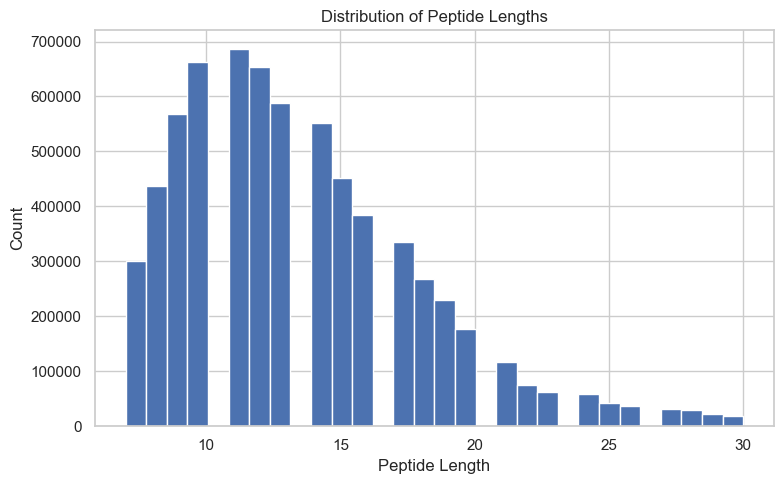

In [5]:
seq_lengths = np.sum(seqs != 0, axis=1)

length_stats = pd.DataFrame({
    "Statistic": [
        "Min",
        "Max",
        "Mean",
        "Median",
        "Std",
        "P90",
        "P95"
    ],
    "Value": [
        seq_lengths.min(),
        seq_lengths.max(),
        seq_lengths.mean(),
        np.median(seq_lengths),
        seq_lengths.std(),
        np.percentile(seq_lengths, 90),
        np.percentile(seq_lengths, 95),
    ]
})

print("\nSequence Length Statistics")
print(length_stats)

# save table
length_stats.to_csv("sequence_length_statistics.csv", index=False)

# histogram
plt.figure(figsize=(8, 5))
plt.hist(seq_lengths, bins=30)
plt.xlabel("Peptide Length")
plt.ylabel("Count")
plt.title("Distribution of Peptide Lengths")
plt.tight_layout()
plt.savefig("seq_length_distribution.png", dpi=300)
plt.show()



Charge Distribution
   Charge    Count  Percentage
0       1      706    0.010401
1       2  4024541   59.289639
2       3  2308545   34.009543
3       4   425674    6.271040
4       5    26653    0.392653
5       6     1814    0.026724



Charge Distribution
   Charge    Count  Percentage
0       1      706    0.010401
1       2  4024541   59.289639
2       3  2308545   34.009543
3       4   425674    6.271040
4       5    26653    0.392653
5       6     1814    0.026724


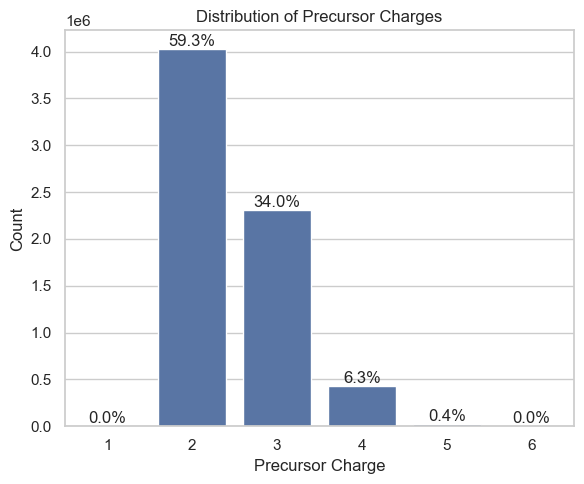

In [6]:
charge_counts = pd.Series(charges).value_counts().sort_index()

charge_table = pd.DataFrame({
    "Charge": charge_counts.index,
    "Count": charge_counts.values,
    "Percentage": charge_counts.values / len(charges) * 100
})

print("\nCharge Distribution")
print(charge_table)

# charge_table.to_csv("charge_distribution.csv", index=False)

plt.figure(figsize=(6, 5))
sns.barplot(
    x=charge_table["Charge"],
    y=charge_table["Count"]
)

plt.xlabel("Precursor Charge")
plt.ylabel("Count")
plt.title("Distribution of Precursor Charges")

for i, row in charge_table.iterrows():
    plt.text(
        i,
        row["Count"],
        f"{row['Percentage']:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig("charge_distribution.png", dpi=300)
plt.show()

e:\Dai hoc\2526I\dacn\flow-matching\.venv\Lib\site-packages\numpy\_core\_methods.py:170: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


e:\Dai hoc\2526I\dacn\flow-matching\.venv\Lib\site-packages\numpy\_core\_methods.py:170: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)



Intensity Statistics
            Statistic      Value
0                 Min  -1.000000
1                 Max   1.000000
2                Mean  -0.618652
3              Median  -1.000000
4                 Std        inf
5  Non-zero ratio (%)  77.584336
6      Zero ratio (%)  22.415664


e:\Dai hoc\2526I\dacn\flow-matching\.venv\Lib\site-packages\numpy\_core\_methods.py:170: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)



Intensity Statistics
            Statistic      Value
0                 Min  -1.000000
1                 Max   1.000000
2                Mean  -0.618652
3              Median  -1.000000
4                 Std        inf
5  Non-zero ratio (%)  77.584336
6      Zero ratio (%)  22.415664


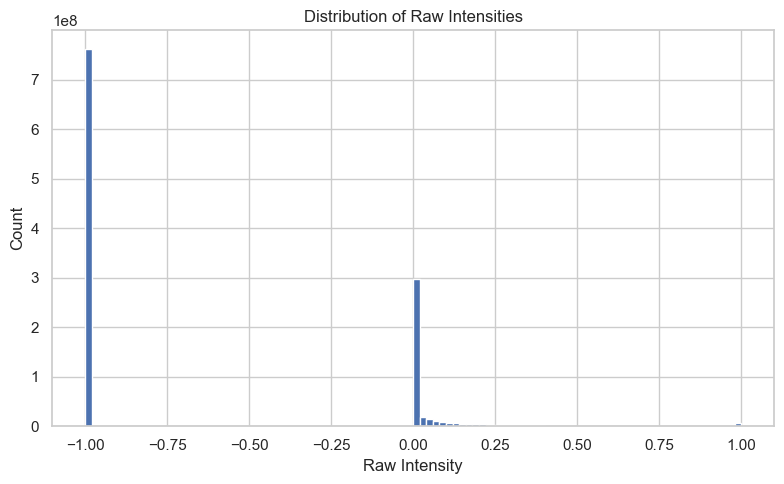

e:\Dai hoc\2526I\dacn\flow-matching\.venv\Lib\site-packages\numpy\_core\_methods.py:170: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)



Intensity Statistics
            Statistic      Value
0                 Min  -1.000000
1                 Max   1.000000
2                Mean  -0.618652
3              Median  -1.000000
4                 Std        inf
5  Non-zero ratio (%)  77.584336
6      Zero ratio (%)  22.415664


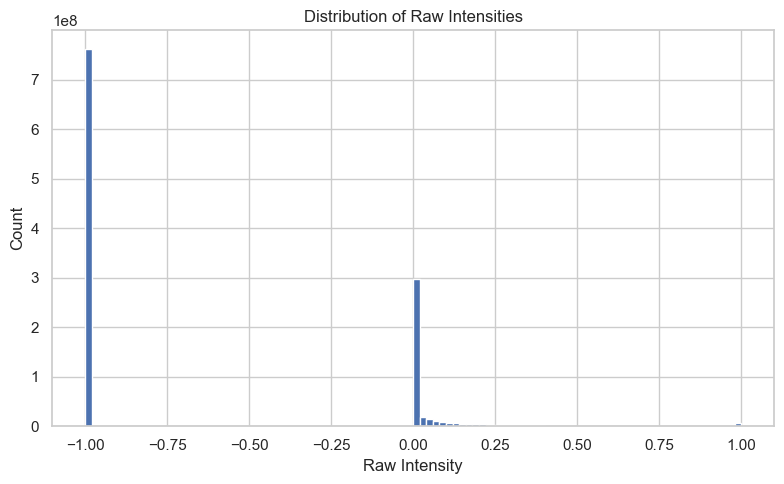


Non-zero Peaks Statistics
  Statistic      Value
0       Min   3.000000
1       Max  89.000000
2      Mean  22.833945
3    Median  22.000000
4       Std   8.500450


e:\Dai hoc\2526I\dacn\flow-matching\.venv\Lib\site-packages\numpy\_core\_methods.py:170: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)



Intensity Statistics
            Statistic      Value
0                 Min  -1.000000
1                 Max   1.000000
2                Mean  -0.618652
3              Median  -1.000000
4                 Std        inf
5  Non-zero ratio (%)  77.584336
6      Zero ratio (%)  22.415664


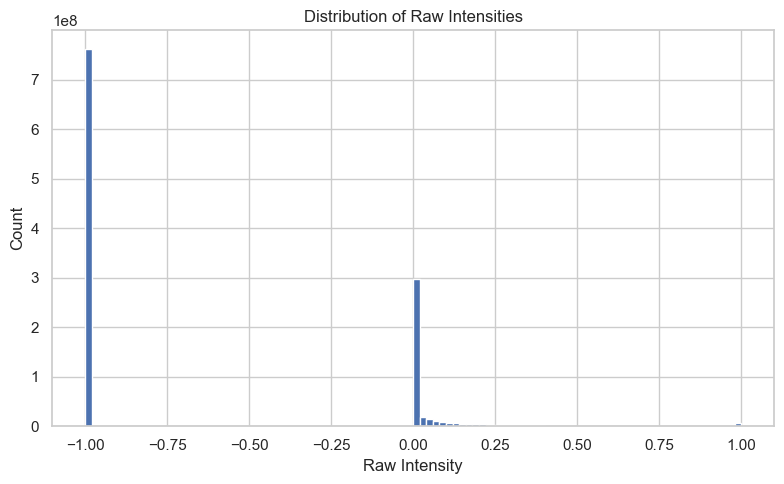


Non-zero Peaks Statistics
  Statistic      Value
0       Min   3.000000
1       Max  89.000000
2      Mean  22.833945
3    Median  22.000000
4       Std   8.500450


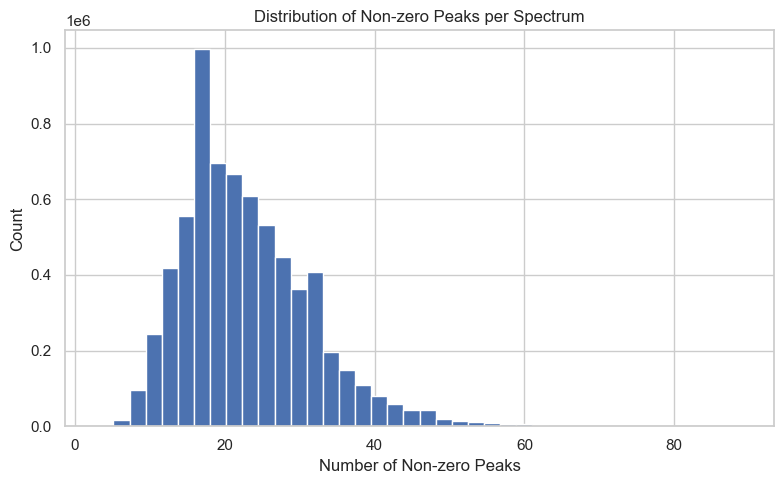

In [7]:

# ============================================================
# INTENSITY ANALYSIS
# ============================================================

flat_intensity = intensities.flatten()

# remove NaN / Inf if exists
flat_intensity = flat_intensity[np.isfinite(flat_intensity)]

# basic stats
intensity_stats = pd.DataFrame({
    "Statistic": [
        "Min",
        "Max",
        "Mean",
        "Median",
        "Std",
        "Non-zero ratio (%)",
        "Zero ratio (%)"
    ],
    "Value": [
        flat_intensity.min(),
        flat_intensity.max(),
        flat_intensity.mean(),
        np.median(flat_intensity),
        flat_intensity.std(),
        np.mean(flat_intensity != 0) * 100,
        np.mean(flat_intensity == 0) * 100
    ]
})

print("\nIntensity Statistics")
print(intensity_stats)

intensity_stats.to_csv("intensity_statistics.csv", index=False)

# raw histogram
plt.figure(figsize=(8, 5))
plt.hist(flat_intensity, bins=100)
plt.xlabel("Raw Intensity")
plt.ylabel("Count")
plt.title("Distribution of Raw Intensities")
plt.tight_layout()
plt.savefig("raw_intensity_distribution.png", dpi=300)
plt.show()

# # log histogram
# log_intensity = np.log1p(flat_intensity)

# plt.figure(figsize=(8, 5))
# plt.hist(log_intensity, bins=100)
# plt.xlabel("log(1 + intensity)")
# plt.ylabel("Count")
# plt.title("Distribution of Log-Transformed Intensities")
# plt.tight_layout()
# plt.savefig("log_intensity_distribution.png", dpi=300)
# plt.show()

# ============================================================
# NON-ZERO PEAKS PER SPECTRUM
# ============================================================

nonzero_peaks = np.sum(intensities > 0, axis=1)

nonzero_stats = pd.DataFrame({
    "Statistic": [
        "Min",
        "Max",
        "Mean",
        "Median",
        "Std"
    ],
    "Value": [
        nonzero_peaks.min(),
        nonzero_peaks.max(),
        nonzero_peaks.mean(),
        np.median(nonzero_peaks),
        nonzero_peaks.std()
    ]
})

print("\nNon-zero Peaks Statistics")
print(nonzero_stats)

nonzero_stats.to_csv("nonzero_peak_statistics.csv", index=False)

plt.figure(figsize=(8, 5))
plt.hist(nonzero_peaks, bins=40)
plt.xlabel("Number of Non-zero Peaks")
plt.ylabel("Count")
plt.title("Distribution of Non-zero Peaks per Spectrum")
plt.tight_layout()
plt.savefig("nonzero_peak_distribution.png", dpi=300)
plt.show()

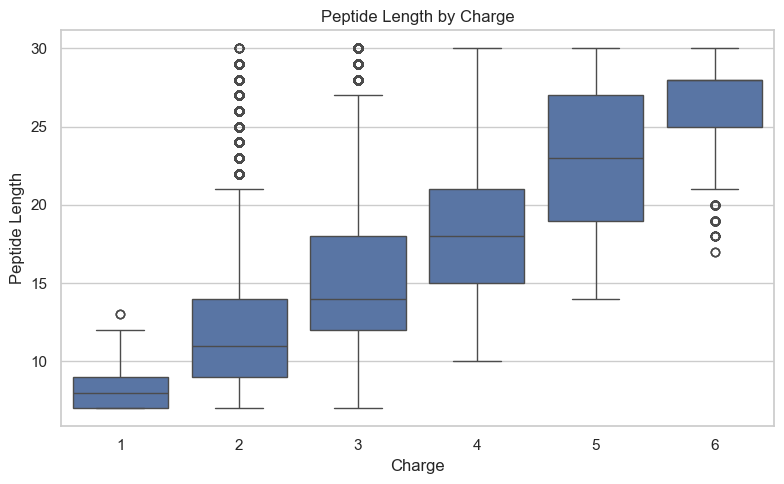

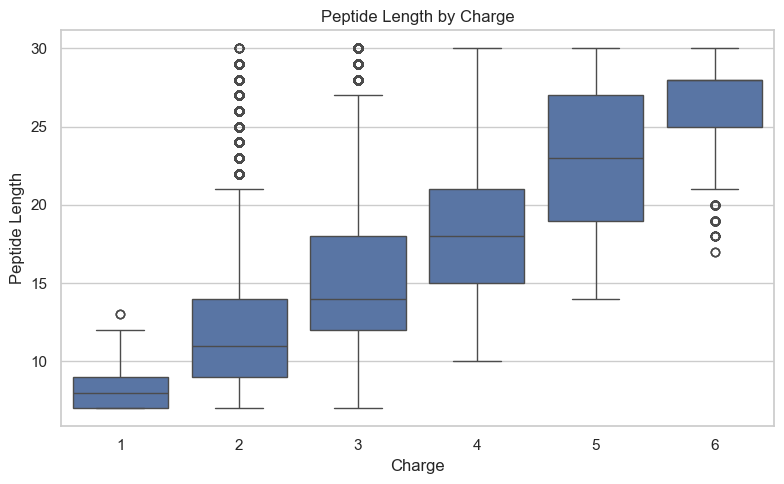

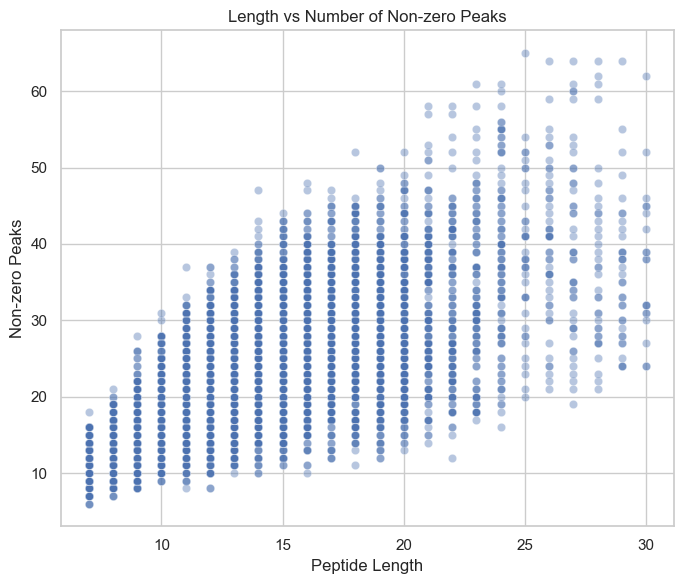

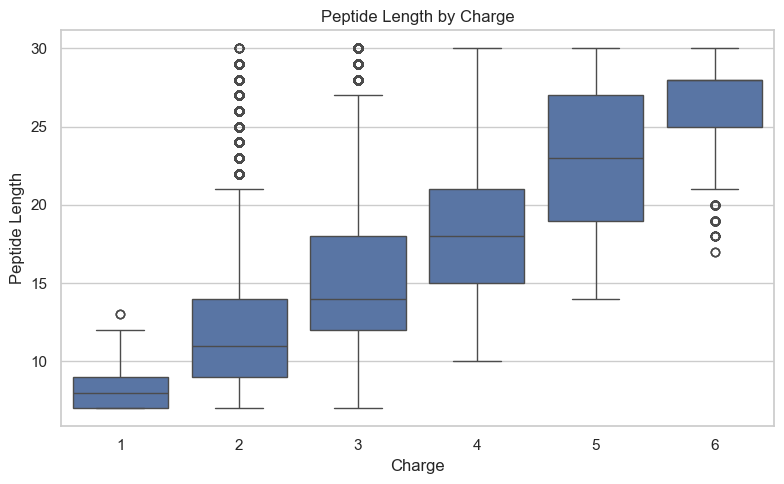

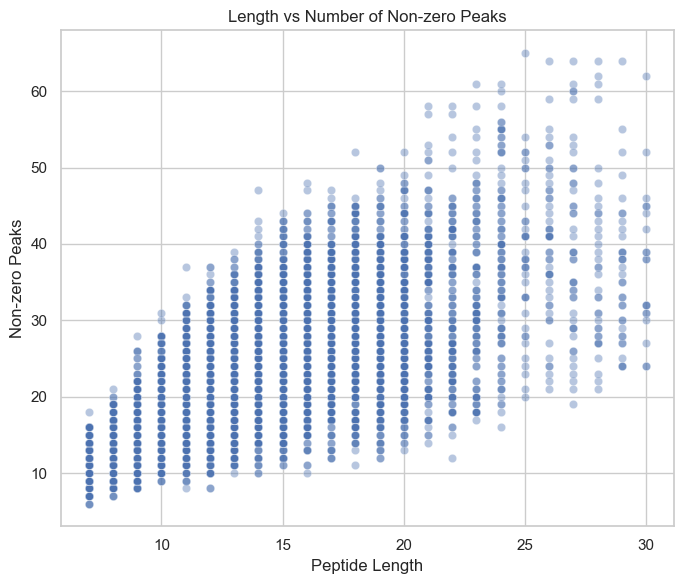

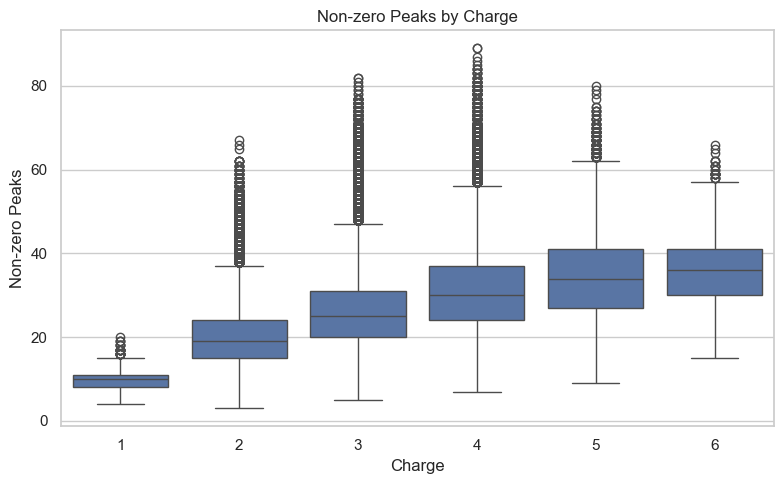

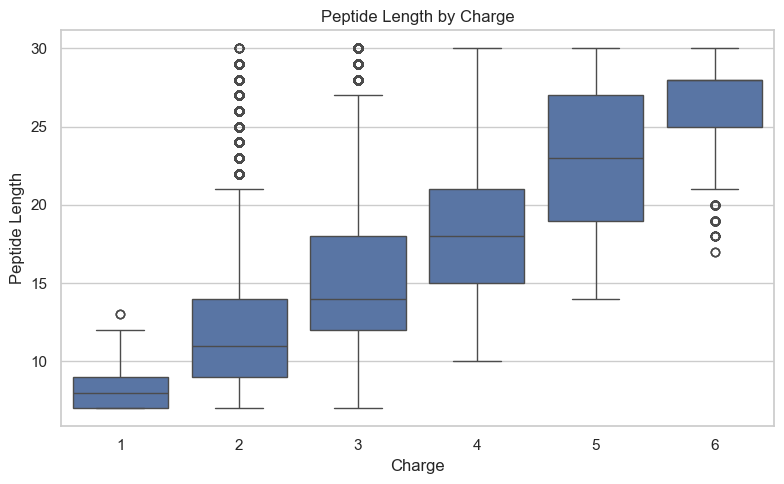

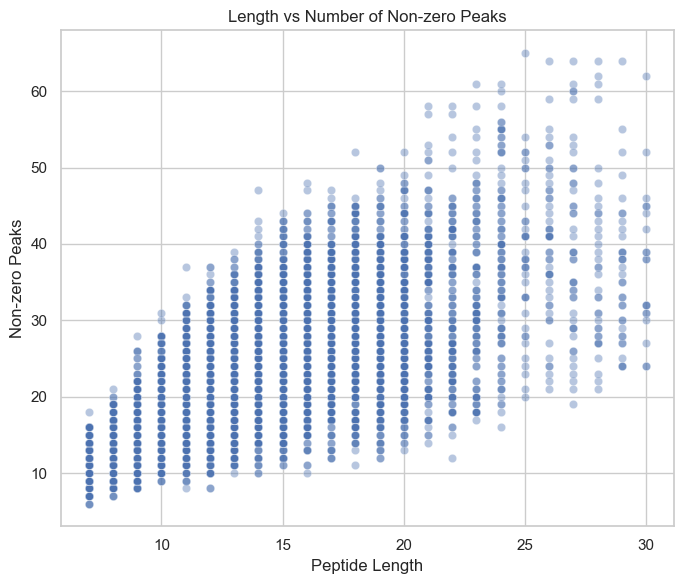

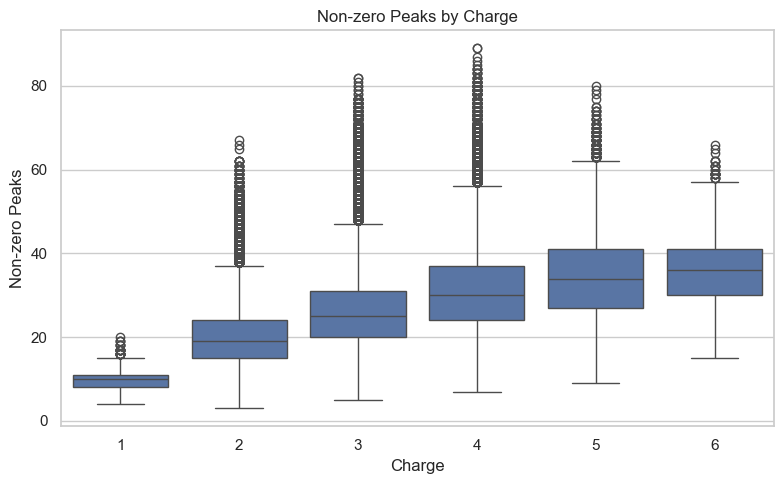


Correlation Matrix
                Length    Charge  NonzeroPeaks
Length        1.000000  0.484579      0.714688
Charge        0.484579  1.000000      0.449095
NonzeroPeaks  0.714688  0.449095      1.000000


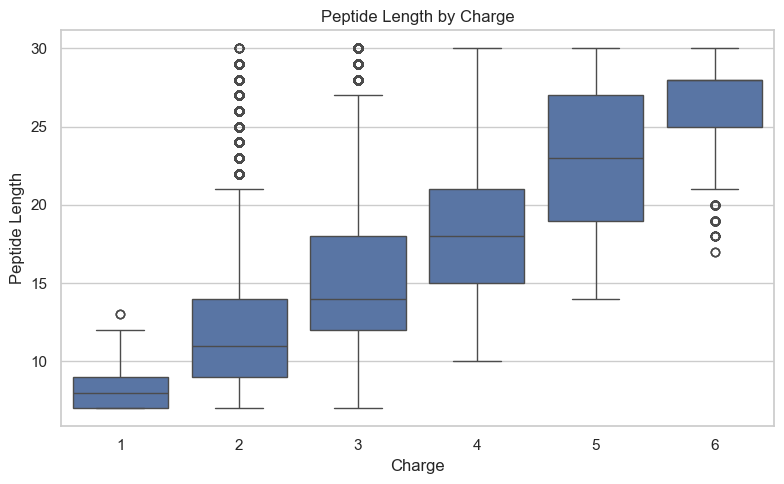

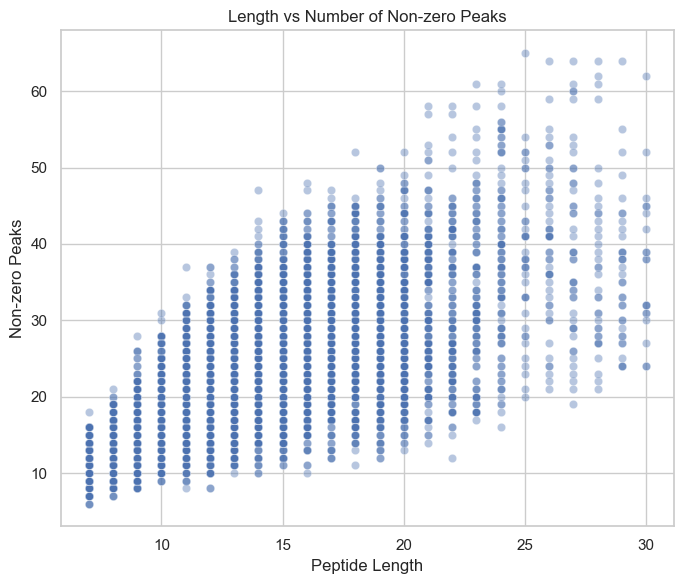

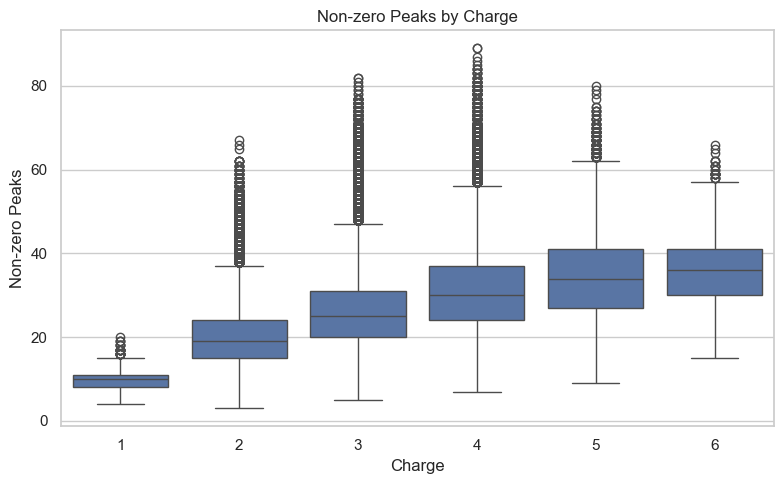


Correlation Matrix
                Length    Charge  NonzeroPeaks
Length        1.000000  0.484579      0.714688
Charge        0.484579  1.000000      0.449095
NonzeroPeaks  0.714688  0.449095      1.000000


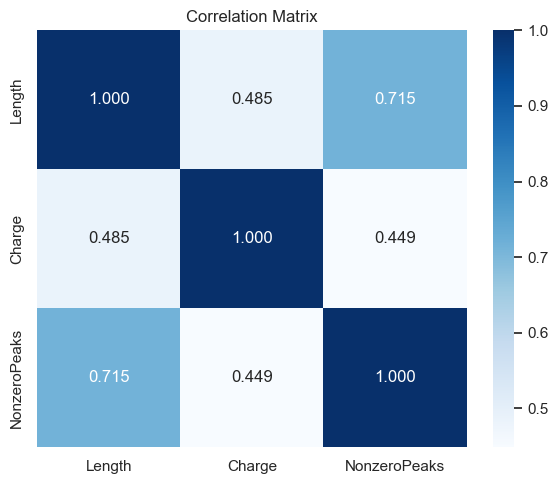


All analysis completed.


In [8]:

# ============================================================
# RELATION: LENGTH vs CHARGE
# ============================================================

length_charge_df = pd.DataFrame({
    "Length": seq_lengths,
    "Charge": charges
})

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=length_charge_df,
    x="Charge",
    y="Length"
)

plt.xlabel("Charge")
plt.ylabel("Peptide Length")
plt.title("Peptide Length by Charge")
plt.tight_layout()
plt.savefig("length_vs_charge_boxplot.png", dpi=300)
plt.show()

# ============================================================
# RELATION: LENGTH vs NON-ZERO PEAKS
# ============================================================

relation_df = pd.DataFrame({
    "Length": seq_lengths,
    "NonzeroPeaks": nonzero_peaks
})

sample_df = relation_df.sample(
    min(10000, len(relation_df)),
    random_state=42
)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=sample_df,
    x="Length",
    y="NonzeroPeaks",
    alpha=0.4
)

plt.xlabel("Peptide Length")
plt.ylabel("Non-zero Peaks")
plt.title("Length vs Number of Non-zero Peaks")
plt.tight_layout()
plt.savefig("length_vs_nonzero_peaks.png", dpi=300)
plt.show()

# ============================================================
# RELATION: CHARGE vs NON-ZERO PEAKS
# ============================================================

charge_peak_df = pd.DataFrame({
    "Charge": charges,
    "NonzeroPeaks": nonzero_peaks
})

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=charge_peak_df,
    x="Charge",
    y="NonzeroPeaks"
)

plt.xlabel("Charge")
plt.ylabel("Non-zero Peaks")
plt.title("Non-zero Peaks by Charge")
plt.tight_layout()
plt.savefig("charge_vs_nonzero_peaks.png", dpi=300)
plt.show()

# ============================================================
# CORRELATION TABLE
# ============================================================

corr_df = pd.DataFrame({
    "Length": seq_lengths,
    "Charge": charges,
    "NonzeroPeaks": nonzero_peaks
})

corr_matrix = corr_df.corr(numeric_only=True)

print("\nCorrelation Matrix")
print(corr_matrix)

corr_matrix.to_csv("correlation_matrix.csv")

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".3f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

print("\nAll analysis completed.")